# Phase 2: Text Preprocessing and LDA Topic Modeling

**Purpose:** Clean contract description text, discover latent topics via LDA with coherence tuning, and generate text features (LDA + TF-IDF) for classification.

**Inputs:** `data/processed/labeled_contracts.csv`
**Outputs:**
- `models/lda_model.gensim` — Trained LDA model
- `data/processed/doc_topic_matrix.parquet` — Document-topic proportion vectors
- `data/processed/tfidf_matrix.npz` — Sparse TF-IDF feature matrix
- `figures/lda_coherence_scores.png` — Coherence vs. K plot

**Key Design Decision:** Two-track approach —
- **Track A (LDA):** Full NLP pipeline on descriptions ≥ 100 characters (lemmatization, custom stop words)
- **Track B (TF-IDF):** Lightweight cleaning on all descriptions

## 1. Environment Setup and Imports

In [1]:
# Data handling
import pandas as pd
import numpy as np
import os
import re
import warnings
from pathlib import Path
from collections import Counter

# Visualization
import matplotlib
import matplotlib.pyplot as plt

# NLP libraries
import nltk
import spacy

# Topic modeling
from gensim.models import LdaModel, CoherenceModel
from gensim.corpora import Dictionary

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse

# Progress tracking
from tqdm import tqdm

# Suppress warnings
warnings.filterwarnings('ignore')

# Download NLTK data if needed
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Load spaCy model
try:
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    print('spaCy model loaded')
except OSError:
    print('Installing spaCy model...')
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'])
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# Reproducibility
RANDOM_STATE = 42

print('Environment configured.')

spaCy model loaded
Environment configured.


## 2. Configuration

In [2]:
# --- File Paths ---
INPUT_FILE = '../data/processed/labeled_contracts.csv'
LDA_MODEL_PATH = '../models/lda_model.gensim'
DICT_PATH = '../models/lda_dictionary.gensim'
DOC_TOPIC_PATH = '../data/processed/doc_topic_matrix.parquet'
TFIDF_MATRIX_PATH = '../data/processed/tfidf_matrix.npz'
TFIDF_FEATURES_PATH = '../data/processed/tfidf_features.txt'
COHERENCE_PLOT_PATH = '../figures/lda_coherence_scores.png'

# Create directories
os.makedirs(os.path.dirname(LDA_MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(DOC_TOPIC_PATH), exist_ok=True)
os.makedirs(os.path.dirname(COHERENCE_PLOT_PATH), exist_ok=True)

# --- Text Preprocessing Parameters ---
MIN_DESCRIPTION_LENGTH = 100  # Minimum chars for Track A (LDA)

# --- LDA Parameters ---
TOPIC_COUNTS = [10, 12, 15, 18, 20, 25, 30]
LDA_PASSES = 10
LDA_ITERATIONS = 50
LDA_ALPHA = 'auto'

# Dictionary filtering
DICT_NO_BELOW = 15
DICT_NO_ABOVE = 0.5

# --- TF-IDF Parameters ---
TFIDF_MAX_FEATURES = 500
TFIDF_MIN_DF = 10
TFIDF_MAX_DF = 0.5
TFIDF_NGRAM_RANGE = (1, 2)

print('Configuration loaded.')

Configuration loaded.


## 3. Load Labeled Dataset

In [2]:
# Load the labeled dataset from Phase 1
print(f'Loading labeled dataset from: {INPUT_FILE}')
df = pd.read_csv(INPUT_FILE)

print(f'Loaded: {len(df):,} rows, {len(df.columns)} columns')
print(f'Columns: {list(df.columns)}')

# Check description column
desc_col = 'description'
if desc_col not in df.columns:
    for col in df.columns:
        if 'description' in col.lower():
            desc_col = col
            break
    print(f'Using description column: {desc_col}')

# Description statistics
df['description_length'] = df[desc_col].fillna('').astype(str).str.len()
print(f'\nDescription statistics:')
print(f'  Non-null: {df[desc_col].notna().sum():,} / {len(df):,}')
print(f'  Mean length: {df["description_length"].mean():.1f} chars')
print(f'  Median length: {df["description_length"].median():.1f} chars')
print(f'  >=100 chars: {(df["description_length"] >= 100).sum():,} ({(df["description_length"] >= 100).mean()*100:.1f}%)')

NameError: name 'INPUT_FILE' is not defined

## 4. Build Custom Stop Word List

In [4]:
# Standard English stop words
from nltk.corpus import stopwords
standard_stops = set(stopwords.words('english'))

# Domain-specific procurement stop words
domain_stops = {
    'far', 'dfars', 'iaw', 'sow', 'pws', 'clin', 'ffp', 'cpff',
    'mod', 'piid', 'fy', 'tbd', 'niin', 'nsn', 'cage', 'uei', 'duns',
    'contract', 'agreement', 'purchase', 'order', 'procurement',
    'government', 'federal', 'agency', 'department',
    'section', 'attachment', 'exhibit', 'appendix',
    'shall', 'will', 'must', 'may', 'hereby', 'herein',
    'provide', 'perform', 'deliver', 'supply', 'furnish',
    'service', 'services', 'item', 'items', 'product', 'products',
}

# Combined stop word set
CUSTOM_STOPS = standard_stops.union(domain_stops)

print(f'Custom stop word list built:')
print(f'  Standard English: {len(standard_stops)}')
print(f'  Domain-specific: {len(domain_stops)}')
print(f'  Total: {len(CUSTOM_STOPS)}')

Custom stop word list built:
  Standard English: 198
  Domain-specific: 47
  Total: 244


## 5. Two-Track Text Preprocessing

In [5]:
def clean_text_lda(text, nlp_pipeline, stop_words):
    """Full preprocessing for LDA track with lemmatization."""
    if pd.isna(text) or not isinstance(text, str):
        return []
    
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    if len(text) < 3:
        return []
    
    doc = nlp_pipeline(text)
    tokens = [
        token.lemma_ 
        for token in doc
        if not token.is_stop 
        and not token.is_punct 
        and not token.like_num
        and len(token.lemma_) > 2
        and token.lemma_.isalpha()
        and token.lemma_.lower() not in stop_words
    ]
    return tokens


def clean_text_tfidf(text):
    """Lightweight preprocessing for TF-IDF track."""
    if pd.isna(text) or not isinstance(text, str):
        return ''
    
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = [t for t in text.split() if len(t) > 2 and t.isalpha()]
    return ' '.join(tokens)


print('Text preprocessing functions defined.')

Text preprocessing functions defined.


### 5.1 Apply Track A Preprocessing (LDA Corpus)

In [6]:
# Track A: Filter to descriptions >= 100 characters
track_a_mask = df['description_length'] >= MIN_DESCRIPTION_LENGTH
track_a_df = df[track_a_mask].copy()

print(f'Track A (LDA) corpus: {len(track_a_df):,} documents')
print(f'   ({track_a_mask.mean()*100:.1f}% of total dataset)')

# Apply spaCy preprocessing with batch processing
print('\nApplying Track A preprocessing (this may take several minutes)...')

track_a_texts = track_a_df[desc_col].fillna('').astype(str).tolist()
track_a_tokens = []
batch_size = 100

for i in tqdm(range(0, len(track_a_texts), batch_size), desc='Processing batches'):
    batch = track_a_texts[i:i+batch_size]
    for doc in nlp.pipe(batch, batch_size=batch_size, disable=['parser', 'ner']):
        tokens = [
            token.lemma_ 
            for token in doc
            if not token.is_stop 
            and not token.is_punct 
            and not token.like_num
            and len(token.lemma_) > 2
            and token.lemma_.isalpha()
            and token.lemma_.lower() not in CUSTOM_STOPS
        ]
        track_a_tokens.append(tokens)

# Store tokens in dataframe
track_a_df['tokens'] = track_a_tokens
track_a_df['token_count'] = track_a_df['tokens'].apply(len)

print(f'\nTrack A preprocessing complete:')
print(f'  Documents with tokens: {(track_a_df["token_count"] > 0).sum():,}')
print(f'  Documents empty after cleaning: {(track_a_df["token_count"] == 0).sum():,}')

Track A (LDA) corpus: 9,357 documents
   (20.6% of total dataset)

Applying Track A preprocessing (this may take several minutes)...



Processing batches:   0%|          | 0/94 [00:00<?, ?it/s]


Processing batches:   1%|          | 1/94 [00:00<00:23,  3.93it/s]


Processing batches:   2%|▏         | 2/94 [00:00<00:21,  4.20it/s]


Processing batches:   3%|▎         | 3/94 [00:00<00:20,  4.44it/s]

...


Processing batches:  97%|█████████▋| 91/94 [00:18<00:00,  4.91it/s]


Processing batches:  98%|█████████▊| 92/94 [00:18<00:00,  5.20it/s]


Processing batches:  99%|█████████▉| 93/94 [00:18<00:00,  5.40it/s]


Processing batches: 100%|██████████| 94/94 [00:18<00:00,  5.05it/s]


Track A preprocessing complete:
  Documents with tokens: 9,357
  Documents empty after cleaning: 0


### 5.2 Drop Empty Documents and Print Token Statistics

In [7]:
# Drop documents with empty token lists
track_a_nonempty = track_a_df[track_a_df['token_count'] > 0].copy()

print(f'Track A after removing empty docs: {len(track_a_nonempty):,} documents')

# Print top 20 most frequent tokens
all_tokens = [token for tokens in track_a_nonempty['tokens'] for token in tokens]
token_freq = Counter(all_tokens)

print(f'\nTop 20 tokens (out of {len(token_freq)} unique):')
for token, count in token_freq.most_common(20):
    print(f'  {token:20s}: {count:6,}')

# Store the final LDA corpus
lda_corpus_df = track_a_nonempty.reset_index(drop=True)
print(f'\nFinal LDA corpus: {len(lda_corpus_df):,} documents')

Track A after removing empty docs: 9,357 documents

Top 20 tokens (out of 14897 unique):
  project             :  1,694
  CONSTRUCTION        :  1,378
  work                :  1,193
  TASK                :  1,052
  BASE                :  1,008
  REPAIR              :    976
  REPLACE             :    944
  building            :    940
  BUILDING            :    938
  PROJECT             :    915
  SYSTEM              :    849
  construction        :    802
  CENTER              :    766
  modification        :    758
  MODIFICATION        :    739
  new                 :    735
  NATIONAL            :    709
  CONTRACTOR          :    679
  AIR                 :    678
  BUILD               :    669

Final LDA corpus: 9,357 documents


### 5.3 Apply Track B Preprocessing (TF-IDF Corpus)

In [8]:
# Track B: Apply lightweight cleaning to ALL descriptions
print('Applying Track B (TF-IDF) preprocessing to all documents...')

df['tfidf_text'] = df[desc_col].fillna('').astype(str).apply(clean_text_tfidf)
df['tfidf_word_count'] = df['tfidf_text'].apply(lambda x: len(x.split()))

print(f'Track B preprocessing complete:')
print(f'  Documents with cleaned text: {(df["tfidf_word_count"] > 0).sum():,}')
print(f'  Documents empty after cleaning: {(df["tfidf_word_count"] == 0).sum():,}')

# Store the final TF-IDF corpus
tfidf_corpus_df = df[df['tfidf_word_count'] > 0].copy()
print(f'\nFinal TF-IDF corpus: {len(tfidf_corpus_df):,} documents')

Applying Track B (TF-IDF) preprocessing to all documents...


Track B preprocessing complete:
  Documents with cleaned text: 45,418
  Documents empty after cleaning: 38

Final TF-IDF corpus: 45,418 documents


## 6. LDA Topic Modeling with Coherence Tuning

In [9]:
# Build Gensim Dictionary from token lists
print('Building Gensim dictionary...')
token_lists = lda_corpus_df['tokens'].tolist()
dictionary = Dictionary(token_lists)

print(f'Initial dictionary: {len(dictionary)} unique tokens')

# Filter extremes
dictionary.filter_extremes(no_below=DICT_NO_BELOW, no_above=DICT_NO_ABOVE)
print(f'After filtering: {len(dictionary)} unique tokens')

# Build bag-of-words corpus
print('Building bag-of-words corpus...')
bow_corpus = [dictionary.doc2bow(tokens) for tokens in token_lists]
print(f'BoW corpus: {len(bow_corpus):,} documents')

# Save dictionary
dictionary.save(DICT_PATH)
print(f'Dictionary saved to: {DICT_PATH}')

Building Gensim dictionary...
Initial dictionary: 14897 unique tokens
After filtering: 1507 unique tokens
Building bag-of-words corpus...
BoW corpus: 9,357 documents


Dictionary saved to: ../models/lda_dictionary.gensim


### 6.1 Coherence Sweep Across Topic Counts

In [10]:
# Run coherence sweep
print('\nRunning coherence sweep (this will take several minutes)...')
print('=' * 60)

coherence_scores = []
topic_models = {}

for k in TOPIC_COUNTS:
    print(f'\nTraining LDA with K={k}...')
    
    lda_model = LdaModel(
        corpus=bow_corpus,
        id2word=dictionary,
        num_topics=k,
        passes=LDA_PASSES,
        iterations=LDA_ITERATIONS,
        alpha=LDA_ALPHA,
        random_state=RANDOM_STATE,
    )
    
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=token_lists,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_score = coherence_model.get_coherence()
    
    print(f'  Coherence (C_v): {coherence_score:.4f}')
    
    coherence_scores.append(coherence_score)
    topic_models[k] = lda_model

print('\n' + '=' * 60)
print('Coherence Sweep Results:')
for k, score in zip(TOPIC_COUNTS, coherence_scores):
    marker = ' <---' if score == max(coherence_scores) else ''
    print(f'  K={k:2d}: {score:.4f}{marker}')

optimal_k = TOPIC_COUNTS[coherence_scores.index(max(coherence_scores))]
print(f'\nOptimal K selected: {optimal_k} (highest coherence: {max(coherence_scores):.4f})')


Running coherence sweep (this will take several minutes)...

Training LDA with K=10...


  Coherence (C_v): 0.4228

Training LDA with K=12...


  Coherence (C_v): 0.4141

Training LDA with K=15...


  Coherence (C_v): 0.4150

Training LDA with K=18...


  Coherence (C_v): 0.4273

Training LDA with K=20...


  Coherence (C_v): 0.4036

Training LDA with K=25...


  Coherence (C_v): 0.3926

Training LDA with K=30...


  Coherence (C_v): 0.4148

Coherence Sweep Results:
  K=10: 0.4228
  K=12: 0.4141
  K=15: 0.4150
  K=18: 0.4273 <---
  K=20: 0.4036
  K=25: 0.3926
  K=30: 0.4148

Optimal K selected: 18 (highest coherence: 0.4273)


### 6.2 Plot and Save Coherence Curve

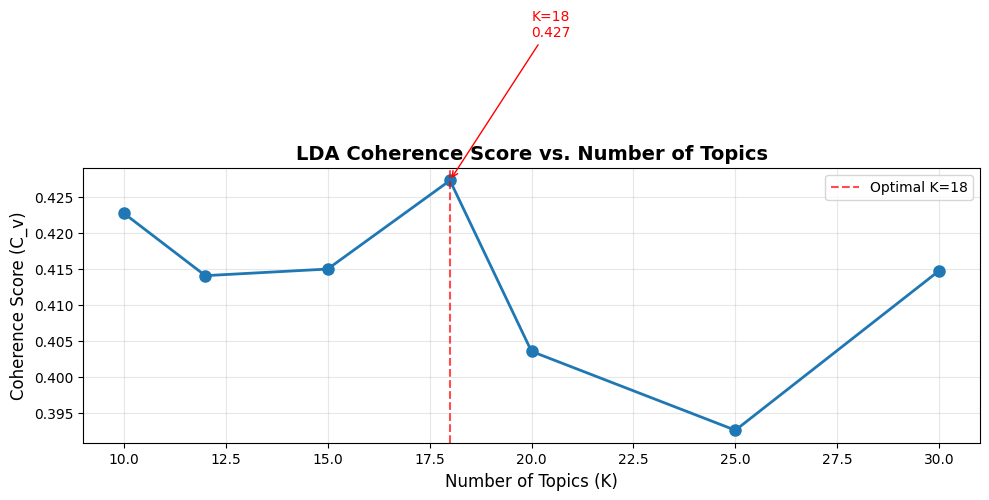

Coherence plot saved to: ../figures/lda_coherence_scores.png


In [11]:
# Create coherence plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(TOPIC_COUNTS, coherence_scores, marker='o', linewidth=2, markersize=8)
ax.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal K={optimal_k}')
ax.set_xlabel('Number of Topics (K)', fontsize=12)
ax.set_ylabel('Coherence Score (C_v)', fontsize=12)
ax.set_title('LDA Coherence Score vs. Number of Topics', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Annotate optimal point
optimal_idx = TOPIC_COUNTS.index(optimal_k)
ax.annotate(
    f'K={optimal_k}\n{coherence_scores[optimal_idx]:.3f}',
    xy=(optimal_k, coherence_scores[optimal_idx]),
    xytext=(optimal_k + 2, coherence_scores[optimal_idx] + 0.02),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10,
    color='red'
)

plt.tight_layout()
plt.savefig(COHERENCE_PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f'Coherence plot saved to: {COHERENCE_PLOT_PATH}')

### 6.3 Train Final LDA Model with Optimal K

In [12]:
# Use the already-trained model for optimal K
final_lda = topic_models[optimal_k]

# Save the final model
final_lda.save(LDA_MODEL_PATH)
print(f'Final LDA model saved to: {LDA_MODEL_PATH}')

# Print top words per topic
print(f'\nTop 10 words per topic (K={optimal_k}):')
print('=' * 60)

topic_labels = {}

for topic_id in range(optimal_k):
    top_words = final_lda.show_topic(topic_id, topn=10)
    words_str = ', '.join([f'{word} ({prob:.3f})' for word, prob in top_words])
    
    top_3_words = [word for word, _ in top_words[:3]]
    topic_label = f"Topic {topic_id}: {' | '.join(top_3_words)}"
    topic_labels[topic_id] = topic_label
    
    print(f'\n{topic_label}')
    print(f'  {words_str}')

# Store topic labels
lda_corpus_df.attrs['topic_labels'] = topic_labels
lda_corpus_df.attrs['optimal_k'] = optimal_k

Final LDA model saved to: ../models/lda_model.gensim

Top 10 words per topic (K=18):

Topic 0: COUNTY | NATIONAL | RIVER
  COUNTY (0.073), NATIONAL (0.057), RIVER (0.049), FORCE (0.042), ROAD (0.041), TEXAS (0.041), PROJECT (0.037), CHANNEL (0.022), LAKE (0.022), PARK (0.021)

Topic 1: TASK | AWARD | CONSTRUCTION
  TASK (0.199), AWARD (0.092), CONSTRUCTION (0.063), idiq (0.043), MULTIPLE (0.039), PROJECT (0.036), matoc (0.030), project (0.026), number (0.022), BASE (0.019)

Topic 2: OFFICE | WASHINGTON | AIRFIELD
  OFFICE (0.062), WASHINGTON (0.050), AIRFIELD (0.040), MACC (0.028), RUNWAY (0.023), WEATHER (0.023), building (0.022), AVE (0.019), CREDIT (0.018), AVENUE (0.016)

Topic 3: new | FIRE | SYSTEM
  new (0.071), FIRE (0.064), SYSTEM (0.046), ELECTRICAL (0.043), exist (0.035), STORAGE (0.029), building (0.028), installation (0.023), tank (0.021), SYSTEMS (0.020)

Topic 4: NAVAL | reason | SUPPORT
  NAVAL (0.095), reason (0.057), SUPPORT (0.037), levee (0.031), UNITED (0.025), REP

### 6.4 Extract Document-Topic Matrix

In [13]:
# Extract topic proportions for each document
print('Extracting document-topic proportions...')

topic_vectors = []
for doc_bow in tqdm(bow_corpus, desc='Processing documents'):
    topic_dist = final_lda.get_document_topics(doc_bow, minimum_probability=0)
    
    topic_vec = np.zeros(optimal_k)
    for topic_id, prob in topic_dist:
        topic_vec[topic_id] = prob
    
    topic_vectors.append(topic_vec)

# Convert to DataFrame
topic_columns = [f'topic_{i}' for i in range(optimal_k)]
topic_df = pd.DataFrame(topic_vectors, columns=topic_columns)

# Add PIID for joining with main dataset
topic_df['piid'] = lda_corpus_df['piid'].values

# Verify topic proportions sum to ~1.0
topic_sums = topic_df[topic_columns].sum(axis=1)
print(f'Document-topic matrix created: {len(topic_df):,} rows x {optimal_k} topics')
print(f'  Mean topic sum per doc: {topic_sums.mean():.4f}')

# Save document-topic matrix
topic_df.to_parquet(DOC_TOPIC_PATH, index=False)
print(f'Document-topic matrix saved to: {DOC_TOPIC_PATH}')

Extracting document-topic proportions...



Processing documents:   0%|          | 0/9357 [00:00<?, ?it/s]


Processing documents:   9%|▊         | 802/9357 [00:00<00:01, 8019.07it/s]


Processing documents:  17%|█▋        | 1604/9357 [00:00<00:01, 7449.77it/s]


Processing documents:  25%|██▌       | 2352/9357 [00:00<00:00, 7144.13it/s]

...


Processing documents:  80%|███████▉  | 7468/9357 [00:01<00:00, 7311.18it/s]


Processing documents:  88%|████████▊ | 8201/9357 [00:01<00:00, 7305.13it/s]


Processing documents:  95%|█████████▌| 8933/9357 [00:01<00:00, 7106.89it/s]


Processing documents: 100%|██████████| 9357/9357 [00:01<00:00, 7088.41it/s]

Document-topic matrix created: 9,357 rows x 18 topics
  Mean topic sum per doc: 1.0000
Document-topic matrix saved to: ../data/processed/doc_topic_matrix.parquet


## 7. TF-IDF Feature Extraction

In [14]:
# Prepare corpus for TF-IDF
tfidf_texts = tfidf_corpus_df['tfidf_text'].tolist()

print(f'TF-IDF corpus: {len(tfidf_texts):,} documents')

# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
    ngram_range=TFIDF_NGRAM_RANGE,
    stop_words='english'
)

print(f'\nFitting TF-IDF...')
print(f'  max_features: {TFIDF_MAX_FEATURES}')

# Fit and transform
tfidf_matrix = tfidf_vectorizer.fit_transform(tfidf_texts)

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')

# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f'  Actual features: {len(feature_names)}')

# Show top features by mean TF-IDF score
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
top_feature_indices = mean_tfidf.argsort()[-20:][::-1]

print(f'\nTop 20 TF-IDF features by mean score:')
for idx in top_feature_indices:
    print(f'  {feature_names[idx]:25s}: {mean_tfidf[idx]:.4f}')

# Save TF-IDF matrix
sparse.save_npz(TFIDF_MATRIX_PATH, tfidf_matrix)
# Save PIIDs for alignment in notebook 06 (fixes B2/B3)
TFIDF_PIIDS_PATH = '../data/processed/tfidf_corpus_piids.txt'
with open(TFIDF_PIIDS_PATH, 'w', encoding='utf-8') as f:
    for p in tfidf_corpus_df['piid'].astype(str):
        f.write(f'{p}\n')
print(f'TF-IDF PIIDs saved to: {TFIDF_PIIDS_PATH}')
print(f'\nTF-IDF matrix saved to: {TFIDF_MATRIX_PATH}')

# Save feature names
with open(TFIDF_FEATURES_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(feature_names))
print(f'Feature names saved to: {TFIDF_FEATURES_PATH}')

TF-IDF corpus: 45,418 documents

Fitting TF-IDF...
  max_features: 500


TF-IDF matrix shape: (45418, 500)
  Actual features: 500

Top 20 TF-IDF features by mean score:
  igf                      : 0.0883
  repair                   : 0.0581
  igf igf                  : 0.0440
  replace                  : 0.0325
  building                 : 0.0324
  bldg                     : 0.0318
  construction             : 0.0311
  project                  : 0.0273
  repairs                  : 0.0212
  replacement              : 0.0198
  roof                     : 0.0183
  renovation               : 0.0182
  contract                 : 0.0177
  base                     : 0.0173
  renovate                 : 0.0167
  hvac                     : 0.0158
  construct                : 0.0157
  facility                 : 0.0153
  design                   : 0.0138
  water                    : 0.0132


TF-IDF PIIDs saved to: ../data/processed/tfidf_corpus_piids.txt

TF-IDF matrix saved to: ../data/processed/tfidf_matrix.npz
Feature names saved to: ../data/processed/tfidf_features.txt


## 8. Summary and Next Steps

In [15]:
# Final summary
print('=' * 70)
print('PHASE 2 COMPLETE: Text Preprocessing and LDA')
print('=' * 70)
print('\nText Preprocessing Summary:')
print(f'  Track A (LDA): {len(lda_corpus_df):,} documents')
print(f'  Track B (TF-IDF): {len(tfidf_corpus_df):,} documents')

print('\nLDA Topic Modeling:')
print(f'  Optimal K: {optimal_k} topics')
print(f'  Coherence score: {max(coherence_scores):.4f}')
print(f'  Dictionary size: {len(dictionary)} tokens')

print('\nGenerated Outputs:')
print(f'  1. {LDA_MODEL_PATH}')
print(f'  2. {DICT_PATH}')
print(f'  3. {DOC_TOPIC_PATH}')
print(f'  4. {TFIDF_MATRIX_PATH}')
print(f'  5. {TFIDF_FEATURES_PATH}')
print(f'  6. {COHERENCE_PLOT_PATH}')

print('\n' + '=' * 70)
print('Next Steps: Run 06_classification.ipynb to train 16-model grid')
print('=' * 70)

PHASE 2 COMPLETE: Text Preprocessing and LDA

Text Preprocessing Summary:
  Track A (LDA): 9,357 documents
  Track B (TF-IDF): 45,418 documents

LDA Topic Modeling:
  Optimal K: 18 topics
  Coherence score: 0.4273
  Dictionary size: 1507 tokens

Generated Outputs:
  1. ../models/lda_model.gensim
  2. ../models/lda_dictionary.gensim
  3. ../data/processed/doc_topic_matrix.parquet
  4. ../data/processed/tfidf_matrix.npz
  5. ../data/processed/tfidf_features.txt
  6. ../figures/lda_coherence_scores.png

Next Steps: Run 06_classification.ipynb to train 16-model grid
